https://thecode.media/logisticheskaya-regressiya-chto-eto-takoe-formula-kod-i-primenenie/

In [1]:
import numpy as np

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    # 1. Сигмоида: превращает z в вероятность от 0 до 1
    def _sigmoid(self, z):
        # Добавляем 1e-9, чтобы избежать деления на ноль при e^(-z)
        return 1 / (1 + np.exp(-z))

    # 2. Метод обучения (подбор весов)
    def fit(self, X, y):
        # X - матрица (строки=объекты, столбцы=признаки)
        # y - вектор ответов (0 или 1)
        
        n_samples, n_features = X.shape
        
        # Инициализируем веса маленькими числами
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Цикл обучения (градиентный спуск)
        for _ in range(self.n_iterations):
            # Шаг А: Считаем линейную комбинацию (z = X*w + b)
            linear_model = np.dot(X, self.weights) + self.bias
            
            # Шаг Б: Применяем сигмоиду, получаем предсказанные вероятности
            y_predicted = self._sigmoid(linear_model)

            # Шаг В: Считаем градиенты (производные функции потерь)
            # dJ/dw = (1/n) * X.T * (y_pred - y)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            # dJ/db = (1/n) * sum(y_pred - y)
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Шаг Г: Обновляем веса, делая шаг против градиента
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    # 3. Метод предсказания вероятности
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    # 4. Метод предсказания класса (0 или 1)
    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        # Если вероятность >= порога, возвращаем 1, иначе 0
        return (probabilities >= threshold).astype(int)

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Генерируем 200 точек для бинарной классификации
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, random_state=42)

# Делим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Создаем и обучаем нашу модель
model = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=1500)
model.fit(X_train, y_train)

# 2. Делаем предсказания
y_pred = model.predict(X_test)
predictions_proba = model.predict_proba(X_test)

# 3. Считаем точность (Accuracy) вручную
accuracy = np.mean(y_pred == y_test)
print(f"Точность модели: {accuracy * 100:.2f}%")

# Выведем первые 5 предсказаний и их вероятности
print("\nПервые 5 вероятностей:")
print(predictions_proba[:5].round(3))
print("Соответствующие классы (True):", y_test[:5])

Точность модели: 87.50%

Первые 5 вероятностей:
[0.079 0.713 0.719 0.651 0.825]
Соответствующие классы (True): [0 0 0 1 1]


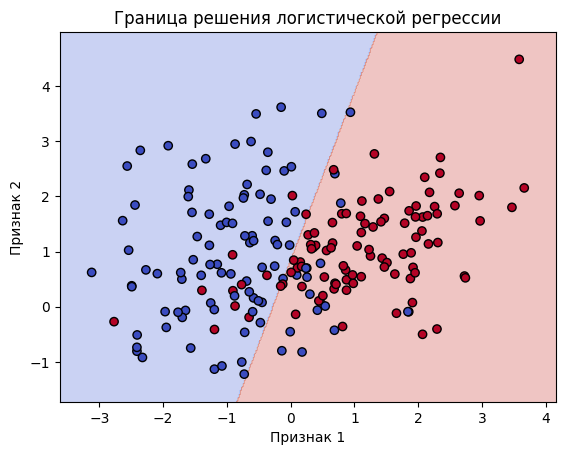

In [3]:
# Функция для отрисовки разделяющей линии
def plot_decision_boundary(X, y, model):
    # Определяем границы графика
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Создаем сетку точек
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Предсказываем вероятности для всей сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Рисуем цветные области
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    # Рисуем точки данных
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title("Граница решения логистической регрессии")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.show()

plot_decision_boundary(X, y, model)